# Test Nemotron-Parse

Downloaded to sample_image.png


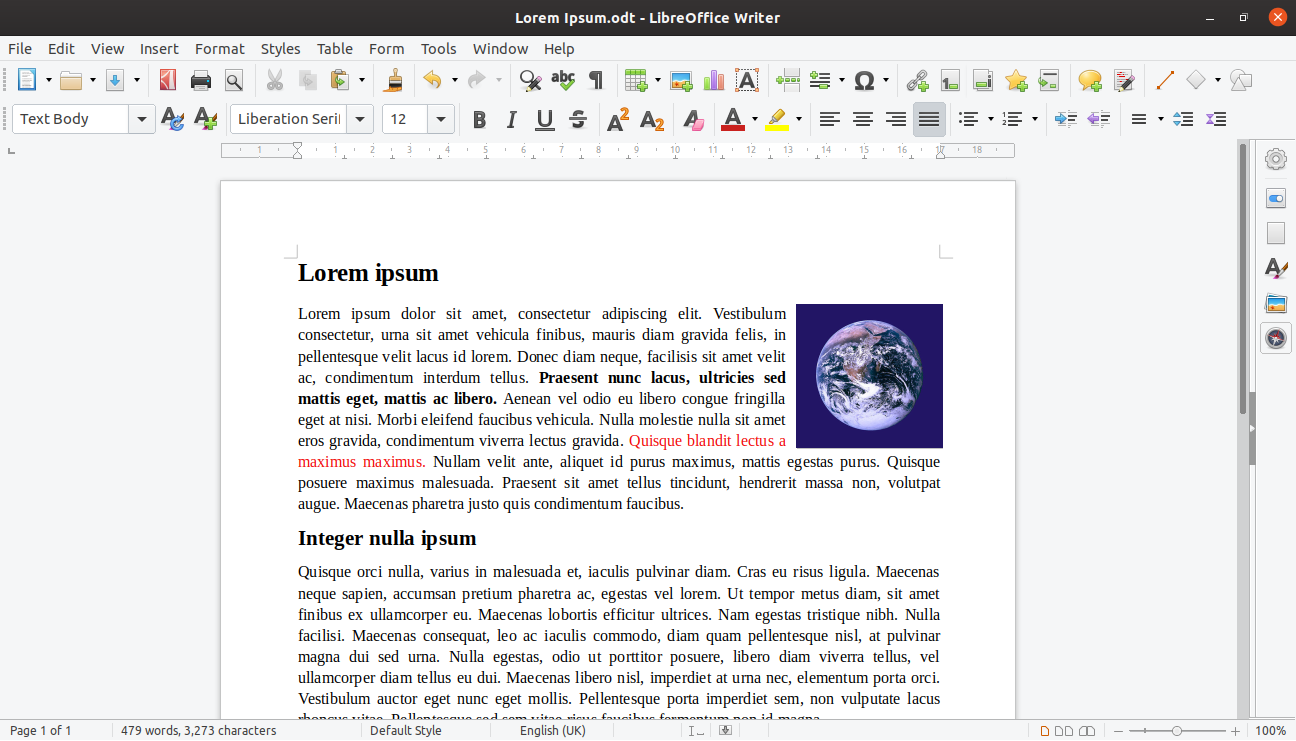

In [1]:
# Download a sample image
import requests

url = "https://upload.wikimedia.org/wikipedia/commons/c/c3/LibreOffice_Writer_6.3.png"
image_path = "sample_image.png"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}
r = requests.get(url, headers=headers)
r.raise_for_status()
with open(image_path, "wb") as f:
    f.write(r.content)
print(f"Downloaded to {image_path}")

from IPython.display import Image, display
display(Image(filename=image_path, width=400))

*Sample image: [LibreOffice Writer 6.3](https://commons.wikimedia.org/wiki/File:LibreOffice_Writer_6.3.png) by [Hatas](https://commons.wikimedia.org/wiki/User:Hatas), Wikimedia Commons, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/deed.en).*

In [2]:
import base64
import os
from openai import OpenAI

IMAGE_MIME = {"png": "image/png", "jpg": "image/jpeg", "jpeg": "image/jpeg", "webp": "image/webp"}

def get_extension(filename):
    _, ext = os.path.splitext(filename)
    return ext[1:].lower()

def encode_image_base64(image_path: str) -> str:
    ext = get_extension(image_path)
    if ext not in IMAGE_MIME:
        raise ValueError(f"Unsupported image format: {ext}")
    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{IMAGE_MIME[ext]};base64,{b64}"

client = OpenAI(
    base_url="http://localhost:8002/v1",
    api_key="not-needed",
)

try:
    print(f"Encoding {image_path} as base64...")
    image_url = encode_image_base64(image_path)
    completion = client.chat.completions.create(
        model="nvidia/nemotron-parse",
        tools=[{"type": "function", "function": {"name": "markdown_bbox"}}],
        messages=[
            {"role": "user", "content": [{"type": "image_url", "image_url": {"url": image_url}}]},
        ],
        temperature=0,
        max_tokens=256
    )
    print("Parse request: Success")
    raw = completion.model_dump() if hasattr(completion, "model_dump") else completion
    print("--- Raw completion (full API response) ---")
    import json
    print(json.dumps(raw, indent=2, default=str))
    if completion.choices and completion.choices[0].message.tool_calls:
        args = completion.choices[0].message.tool_calls[0].function.arguments
        out = json.loads(args)
        text = out.get("text", out) if isinstance(out, dict) else out
        print("--- Extracted text (from tool_calls) ---")
        print(text if isinstance(text, str) else text)
except Exception as e:
    print(f"Parse request: Failed — {e}")

Encoding sample_image.png as base64...
Parse request: Success
--- Raw completion (full API response) ---
{
  "id": "chatcmpl-f247ba977327451bbbc19a2c94d211c8",
  "choices": [
    {
      "finish_reason": "length",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": null,
        "refusal": null,
        "role": "assistant",
        "annotations": null,
        "audio": null,
        "function_call": null,
        "tool_calls": [
          {
            "id": "chatcmpl-tool-6d70a4e2460d471fbb5b52e558a1d78d",
            "function": {
              "arguments": "[[{\"bbox\": {\"xmin\": 0.39687283950617286, \"ymin\": 0.012581916329284808, \"xmax\": 0.6005839506172839, \"ymax\": 0.03413981106612684}, \"text\": \"**Lorem Ipsum.odt - LibreOffice Writer**\", \"type\": \"Page-header\"}, {\"bbox\": {\"xmin\": 0.22927530864197532, \"ymin\": 0.3517041835357625, \"xmax\": 0.3373617283950617, \"ymax\": 0.3840410256410256}, \"text\": \"## Lorem ipsum\", \"type\": \"Sectio

# Test Embedding Model

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [6]:
from openai import OpenAI

client = OpenAI(
    api_key=os.getenv("NVIDIA_INFERENCE_KEY"),
    base_url="https://inference-api.nvidia.com/v1",
)

try:
    response = client.embeddings.create(
        input=["What is the civil caseload in South Dakota courts?"],
        model="nvidia/nvidia/llama-3.2-nv-embedqa-1b-v2",
        encoding_format="float",
        extra_body={"input_type": "query"},
    )
    print("Embedding request: Success")
    print(response.data[0].embedding)
except Exception as e:
    print(f"Embedding request: Failed — {e}")

Embedding request: Success
[0.004650115966796875, 0.0029449462890625, 0.0163726806640625, 0.00836181640625, 0.0251922607421875, 0.02001953125, 0.01558685302734375, 0.003566741943359375, -0.029388427734375, 0.0114593505859375, -0.00695037841796875, -0.0099334716796875, 0.00128173828125, -0.01084136962890625, -0.0031890869140625, 0.0087738037109375, -0.00836181640625, -0.0264434814453125, 0.0137481689453125, 0.02020263671875, -0.01021575927734375, -0.04638671875, -0.0143585205078125, 0.044219970703125, 0.0253753662109375, -0.03485107421875, 0.01519775390625, -0.008148193359375, -0.0178680419921875, -0.00476837158203125, -0.00347137451171875, 0.04608154296875, -0.034637451171875, -0.00812530517578125, 0.0133514404296875, -0.034027099609375, 0.00920867919921875, -0.028778076171875, 0.037872314453125, -0.01056671142578125, -0.002044677734375, -0.0294189453125, -0.006103515625, -0.03961181640625, -0.020538330078125, 0.01372528076171875, -0.0143585205078125, 0.0208892822265625, -0.02029418945

# Test VLM

In [ ]:
import requests
import os
import base64

query = "Describe the scene"

invoke_url = "https://inference-api.nvidia.com/v1/chat/completions"

# Image-only support for this notebook
IMAGE_MIME = {
    "png": "image/png",
    "jpg": "image/jpeg",
    "jpeg": "image/jpeg",
    "webp": "image/webp",
}


def get_extension(filename):
    _, ext = os.path.splitext(filename)
    return ext[1:].lower()


def encode_image_base64(image_path: str) -> str:
    """Encode image file to base64 data URL."""
    ext = get_extension(image_path)
    if ext not in IMAGE_MIME:
        raise ValueError(f"Unsupported image format: {ext}. Use one of {list(IMAGE_MIME)}")
    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    mime = IMAGE_MIME[ext]
    return f"data:{mime};base64,{b64}"


# Encode single image and build request
print(f"Encoding {image_path} as base64...")
image_url = encode_image_base64(image_path)

content = [
    {"type": "text", "text": query},
    {"type": "image_url", "image_url": {"url": image_url}},
]

headers = {
    "Content-Type": "application/json",
    "Accept": "application/json",
    'Authorization': f'Bearer {os.getenv("NVIDIA_INFERENCE_KEY")}' 
}


messages = [
    {"role": "system", "content": "/think"},
    {"role": "user", "content": content},
]

payload = {
    "max_tokens": 4096,
    "temperature": 1,
    "top_p": 1,
    "frequency_penalty": 0,
    "presence_penalty": 0,
    "messages": messages,
    "model": "nvidia/nvidia/nemotron-nano-12b-v2-vl",
}

try:
    response = requests.post(invoke_url, headers=headers, json=payload)
    response.raise_for_status()
    print("VLM request: Success")
    try:
        print(response.json())
    except ValueError:
        # Response is not JSON (empty or other format)
        print("Response body (raw):", response.text or "(empty)")
except Exception as e:
    print(f"VLM request: Failed — {e}")

Encoding sample_image.png as base64...
VLM request: Failed — 401 Client Error: Unauthorized for url: https://inference-api.nvidia.com/v1/chat/completions
